# Amazon Product Reviews Analysis

This notebook performs text mining and sentiment analysis on Amazon product reviews using natural language processing (NLP) and machine learning techniques.

The analysis explores customer feedback to understand sentiment patterns, discover common topics in reviews, and identify products where written sentiment does not match star ratings.

---

## Project Type
Academic Data Mining / NLP Project

---

## Dataset
Amazon Product Reviews dataset from Kaggle

https://www.kaggle.com/datasets/jillanisofttech/amazon-product-reviews

---

## Methods Used

- TF-IDF vectorization
- Logistic Regression for sentiment prediction
- LDA topic modeling
- Word2Vec embeddings with KMeans clustering
- t-SNE visualization
- PCA visualization
- VADER sentiment analysis

---

## Research Questions

1. Can we predict sentiment from review text?
2. What topics emerge in customer reviews?
3. Which products have the largest mismatch between star rating and written sentiment?

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import os
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [2]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# Ignore common sklearn + future warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore")


In [3]:
df = pd.read_csv("../data/Reviews.csv")
df.info()
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


(568454, 10)

In [4]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [5]:
df = df.dropna(subset=['Summary'])

In [6]:
df.duplicated().sum()

0

In [7]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                    0
Text                       0
dtype: int64

In [8]:
df.shape

(568427, 10)

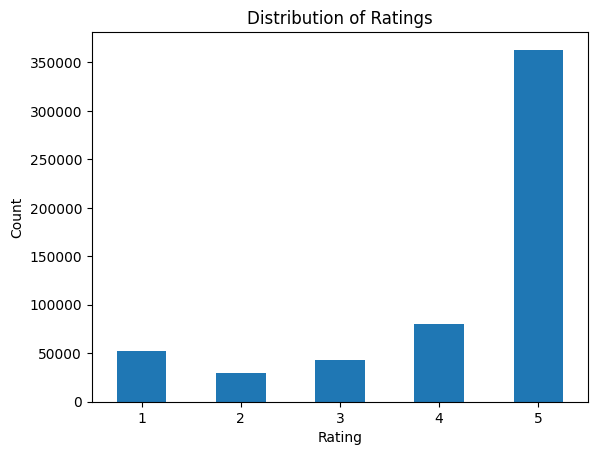

In [9]:
df["Score"].value_counts().sort_index().plot(kind="bar")
plt.xticks(rotation=0)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Distribution of Ratings")
plt.show()

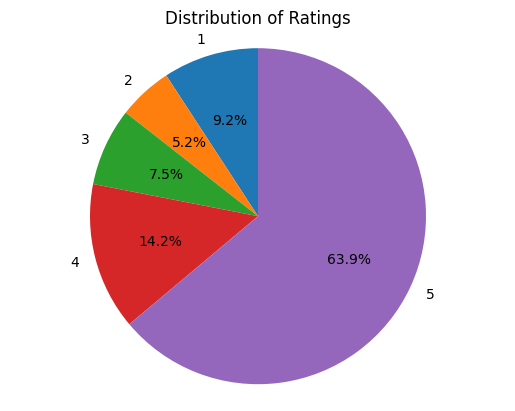

In [10]:
df["Score"].value_counts().sort_index().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.ylabel("")
plt.title("Distribution of Ratings")
plt.axis("equal")
plt.show()

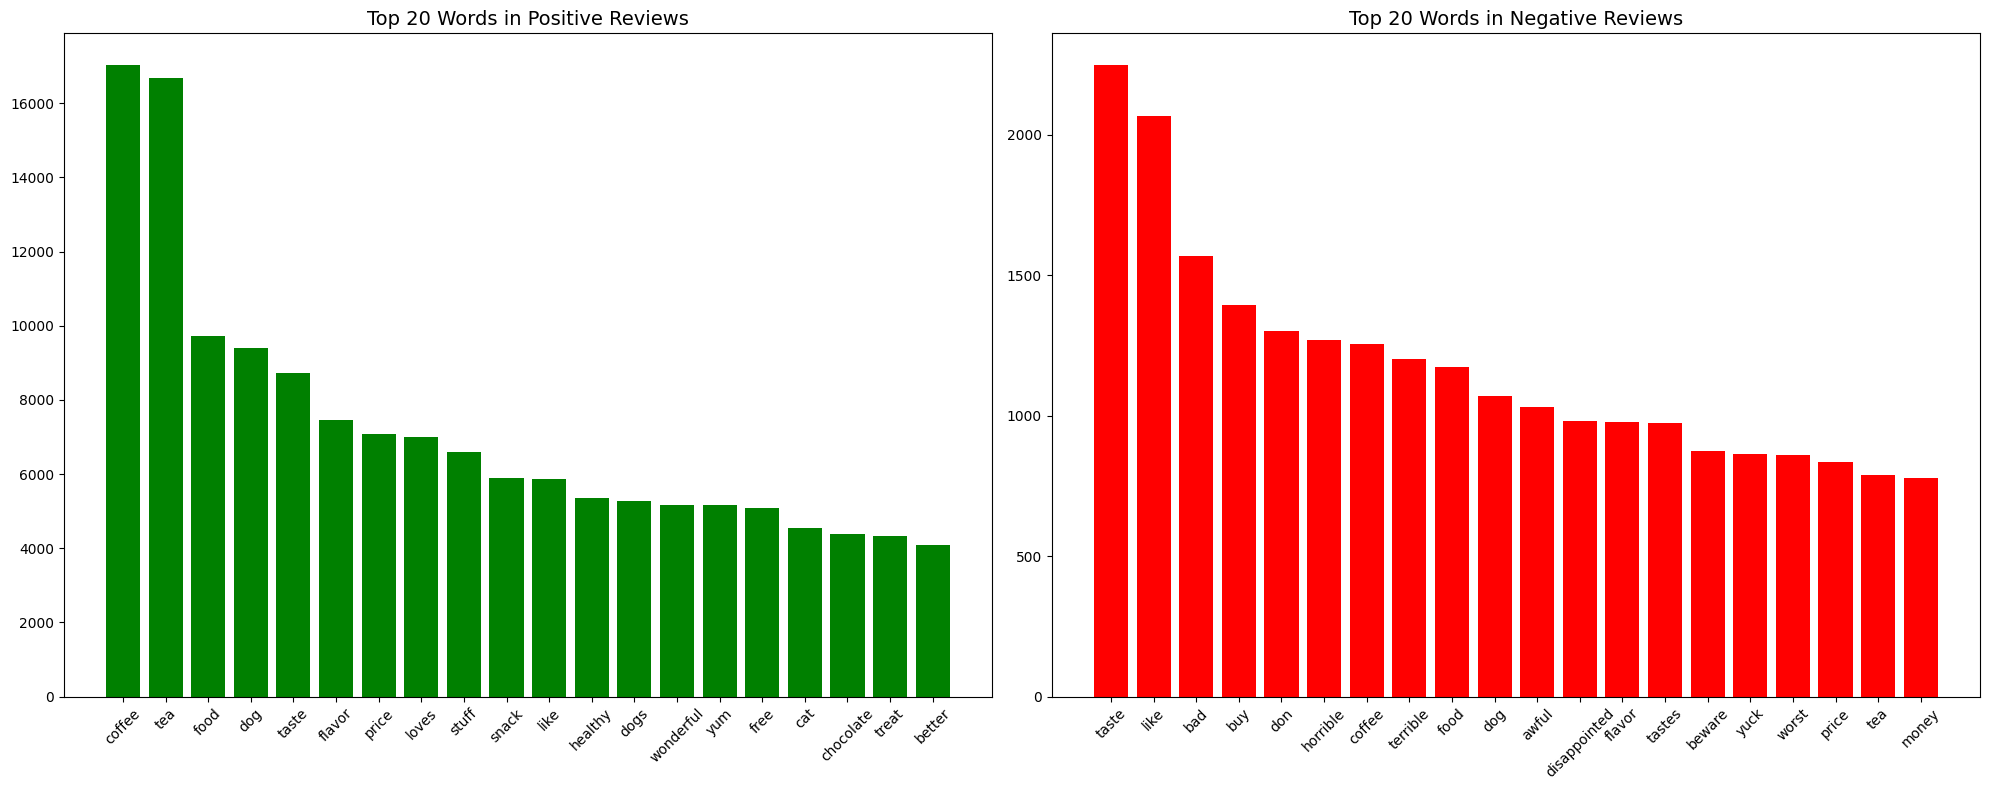

In [11]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import matplotlib.pyplot as plt
import re



def clean_text(text):
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df["clean_summary"] = df["Summary"].apply(clean_text)


def get_top_words(reviews, stop_words, custom_stopwords, top_n=20):
    reviews = reviews.apply(clean_text)
    vectorizer = CountVectorizer(stop_words=stop_words)
    X = vectorizer.fit_transform(reviews)
    word_counts = X.sum(axis=0)
    words_freq = [(word, word_counts[0, idx]) 
                  for word, idx in vectorizer.vocabulary_.items() 
                  if word not in custom_stopwords]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    top_words = words_freq[:top_n]
    words, counts = zip(*top_words)
    return words, counts

nltk_stop_words = list(ENGLISH_STOP_WORDS)
custom_stopwords_freq = [
    'br', 'one', 'review', 'amazon', 'get', 'would', 'also',
    'great', 'good', 'excellent', 'love', 'awesome', 'favorite',
    'best', 'yummy', 'tasty', 'delicious', 'perfect', 'nice',
    'product', 'use', 'using', 'very'
]



positive_reviews = df[df['Score'] == 5]['Summary']
negative_reviews = df[df['Score'] == 1]['Summary']

pos_words, pos_counts = get_top_words(
    positive_reviews, nltk_stop_words, custom_stopwords_freq
)
neg_words, neg_counts = get_top_words(
    negative_reviews, nltk_stop_words, custom_stopwords_freq
)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

axes[0].bar(pos_words, pos_counts, color='green')
axes[0].set_title('Top 20 Words in Positive Reviews', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(neg_words, neg_counts, color='red')
axes[1].set_title('Top 20 Words in Negative Reviews', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [12]:
positive_reviews

0                                 Good Quality Dog Food
4                                           Great taffy
6         Great!  Just as good as the expensive brands!
7                                Wonderful, tasty taffy
8                                            Yay Barley
                              ...                      
568448                    Very large ground spice jars.
568449                              Will not do without
568451                         Perfect for our maltipoo
568452               Favorite Training and reward treat
568453                                      Great Honey
Name: Summary, Length: 363122, dtype: object

In [13]:
negative_reviews

1                            Not as Advertised
12        My Cats Are Not Fans of the New Food
26                             Nasty No flavor
50                               Don't like it
62                              stale product.
                          ...                 
568402                    alternative sweetner
568426                                 rip off
568431                            Mostly water
568432                                 No Good
568433                        Tastes horrible!
Name: Summary, Length: 52268, dtype: object

In [14]:
most_5_star = (
    df[df['Score'] == 5]['ProductId']
    .value_counts()
)

product_most_5_star = most_5_star.idxmax()
count_most_5_star = most_5_star.max()

most_1_star = (
    df[df['Score'] == 1]['ProductId']
    .value_counts()
)

product_most_1_star = most_1_star.idxmax()
count_most_1_star = most_1_star.max()

print(f"Product with MOST 5-star ratings: {product_most_5_star} ({count_most_5_star} reviews)")
print(f"Product with MOST 1-star ratings: {product_most_1_star} ({count_most_1_star} reviews)")

Product with MOST 5-star ratings: B007JFMH8M (624 reviews)
Product with MOST 1-star ratings: B000X1Q1G8 (134 reviews)


In [15]:
df[df['ProductId'] == 'B007JFMH8M']

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,clean_summary
562970,562971,B007JFMH8M,A368Z46FIKHSEZ,"jaimoi ""Appreciator of good music""",0,0,5,1343433600,Delicious!,I love these cookies! Not only are they healt...,delicious
562971,562972,B007JFMH8M,A1JAPP1CXRG57A,"Linda Painchaud-Steinman ""PARK EDGE BOOKS""",0,0,5,1343433600,Great Anytime of Day!,Quaker Soft Baked Oatmeal Cookies with raisins...,great anytime of day
562972,562973,B007JFMH8M,A2Z9JNXPIEL2B9,carwash169,0,0,5,1343433600,Very good!,I am usually not a huge fan of oatmeal cookies...,very good
562973,562974,B007JFMH8M,A31CYJQO3FL586,"P. Titus ""Knitgirlll""",0,0,5,1343433600,Quaker Oats Oatmeal Raisin Mom Voxbox Review C...,I participated in a product review that includ...,quaker oats oatmeal raisin mom voxbox review c...
562974,562975,B007JFMH8M,A2KXQ2EKFF3K2G,Jessica,0,0,5,1343433600,"Quick, simple HEALTHY snack for the kiddos!!!",My kids loved these. I was very pleased to giv...,quick simple healthy snack for the kiddos
...,...,...,...,...,...,...,...,...,...,...,...
563878,563879,B007JFMH8M,A366PSH7KFLRPB,TheRosySnail,0,0,5,1343520000,Yummy!,I loved these cookies and so did my kids. You ...,yummy
563879,563880,B007JFMH8M,A2KV6EYQPKJRR5,Kelley,0,0,5,1343433600,Quaker Soft Baked Cookies,This is a great tasting cookie. It is very sof...,quaker soft baked cookies
563880,563881,B007JFMH8M,A3O7REI0OSV89M,Esme,0,0,4,1343433600,Delicious!,These are great for a quick snack! They are sa...,delicious
563881,563882,B007JFMH8M,A9JS5GQQ6GIQT,Syne,0,0,5,1343433600,yummy,I love the Quaker soft baked cookies. The rea...,yummy


In [16]:
df[df['ProductId'] == 'B000X1Q1G8']

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,clean_summary
117878,117879,B000X1Q1G8,A2IHOUK31N323P,Matthew,1,1,1,1325980800,Disgusting,I know they were trying because most of their ...,disgusting
117879,117880,B000X1Q1G8,A1VJQ5A72CVWTD,melissa anastacia kennedy,1,1,1,1325289600,DONT WAIST YOUR MONEY,ABSOLUTELY the worst peanutbutter i've ever t...,dont waist your money
117880,117881,B000X1Q1G8,A3GAMRRHU5N36L,bpd31770,1,1,1,1323648000,Disgusting,Excrement mixed with splenda is the best way I...,disgusting
117881,117882,B000X1Q1G8,A2IIMX1CS0TIE9,Trist,1,1,1,1323475200,"The ""Yucks"" had it right!","With all the bad reviews, I still wanted to se...",the yucks had it right
117882,117883,B000X1Q1G8,A35WYW1ZSUVKYG,West Side Jeff,1,1,1,1322697600,Truly revolting,Imagine farmers on earth lose the ability to g...,truly revolting
...,...,...,...,...,...,...,...,...,...,...,...
118057,118058,B000X1Q1G8,A1MNHXEMAJNOBD,ari1016,1,1,1,1330905600,Does not live up to the Walden Farms name,I use many of the Walden products and they are...,does not live up to the walden farms name
118058,118059,B000X1Q1G8,A3IP76TGSGY4DA,unsatisfied customer,1,1,1,1330905600,Awful,Do not waste your money. This product is gross...,awful
118059,118060,B000X1Q1G8,A25ISENSACV7SX,"David Natroshvili ""David""",1,1,1,1330300800,"looks really bad ,tastes even worse!!",this tastes really really horrible and plus it...,looks really bad tastes even worse
118060,118061,B000X1Q1G8,A156LB7D9SSF6J,Chris from Michigan,1,1,1,1328313600,Don't waste your money...,I recently received a half price offer for Wal...,don t waste your money


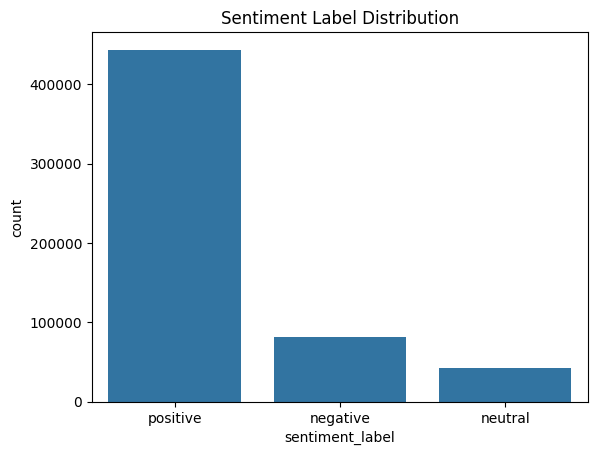

In [17]:
def score_to_sentiment(score):
    if score >= 4:
        return "positive"
    elif score == 3:
        return "neutral"
    else:
        return "negative"

df["sentiment_label"] = df["Score"].apply(score_to_sentiment)

df["sentiment_label"].value_counts()

sns.countplot(x="sentiment_label", data=df)
plt.title("Sentiment Label Distribution")
plt.show()









In [18]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Base English stopwords
stop_words = set(ENGLISH_STOP_WORDS)

# Amazon / review-specific stopwords
custom_stopwords = {
    "product", "amazon", "buy", "bought", "purchase",
    "use", "used", "using",
    "item", "items",
    "review", "reviews",
    "one", "also",
    "really", "much", "very",
    "would", "could", "get", "got",
    "good", "great", "nice", "bad"
}

# Combine both sets
stop_words = stop_words.union(custom_stopwords)

# Test it
print("Number of stopwords:", len(stop_words))
print("Some stopwords:", list(stop_words)[:10])



Number of stopwords: 336
Some stopwords: ['somehow', 'less', 'show', 'become', 'again', 'fire', 'interest', 'must', 'no', 'via']


In [19]:
from sklearn.feature_extraction.text import CountVectorizer

count_vec = CountVectorizer(
    max_df=0.9,
    min_df=10,
    stop_words=list(stop_words)  # <-- convert set to list
)

dtm = count_vec.fit_transform(df["clean_summary"])
print("Document-Term Matrix shape:", dtm.shape)


Document-Term Matrix shape: (568427, 7321)


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    max_df=0.9,
    min_df=10,
    stop_words=list(stop_words)  # <-- convert set to list
)


X = tfidf.fit_transform(df["clean_summary"])
y = df["sentiment_label"]

print("TF-IDF matrix shape:", X.shape)

TF-IDF matrix shape: (568427, 5000)


## 1️⃣ Predicting Sentiment from Review Text

Here we use **TF-IDF features** from review summaries and a **Logistic Regression model** to predict sentiment labels:  
- Positive, Neutral, Negative  
- This answers **Research Question 1**: Can we predict sentiment from the review text?


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Model accuracy:", accuracy)



              precision    recall  f1-score   support

    negative       0.72      0.51      0.60     16301
     neutral       0.59      0.14      0.22      8434
    positive       0.87      0.98      0.92     88951

    accuracy                           0.85    113686
   macro avg       0.73      0.54      0.58    113686
weighted avg       0.83      0.85      0.82    113686

Model accuracy: 0.8467797266154143


## 2️⃣ Discovering Topics with LDA

We use **Latent Dirichlet Allocation (LDA)** to extract topics from review summaries:  
- LDA finds groups of words that often appear together  
- This gives us an **unsupervised view of the main topics** in reviews  
- This is **Approach 1** to answer **Research Question 2**


In [22]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

lda.fit(dtm)


LatentDirichletAllocation(n_components=5, random_state=42)

In [23]:
# Use clean summaries
X_dtm = count_vec.fit_transform(df['clean_summary'])

lda = LatentDirichletAllocation(n_components=4, random_state=42)  # 4 topics
lda.fit(X_dtm)

def show_topics(model, feature_names, top_n=10):
    for idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-top_n-1:-1] 
                     if feature_names[i] not in stop_words]
        print(f"\nTopic {idx + 1}: {', '.join(top_words)}")

show_topics(lda, count_vec.get_feature_names_out())



Topic 1: flavor, dog, food, excellent, price, stuff, loves, better, cat, perfect

Topic 2: taste, favorite, sweet, tasting, chips, way, salt, deal, popcorn, oil

Topic 3: delicious, like, tasty, yummy, snack, just, free, tastes, yum, healthy

Topic 4: best, love, coffee, tea, dogs, awesome, cup, cats, value, green


In [24]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download("vader_lexicon")

sia = SentimentIntensityAnalyzer()

df["sentiment_score"] = df["Summary"].apply(
    lambda x: sia.polarity_scores(str(x))["compound"]
)

df[["Summary", "sentiment_score"]].head()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/rutuu/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,Summary,sentiment_score
0,Good Quality Dog Food,0.4404
1,Not as Advertised,0.0000
2,"""Delight"" says it all",0.0000
3,Cough Medicine,0.0000
4,Great taffy,0.6249


In [25]:
df["rating_score"] = df["Score"].map({
    1: -1,
    2: -0.5,
    3: 0,
    4: 0.5,
    5: 1
})

df[["Score", "rating_score"]].head()


,Score,rating_score
0,5,1.0
1,1,-1.0
2,4,0.5
3,2,-0.5
4,5,1.0


In [26]:
df["discrepancy"] = abs(df["sentiment_score"] - df["rating_score"])

df[["Summary", "Score", "sentiment_score", "discrepancy"]].head()


,Summary,Score,sentiment_score,discrepancy
0,Good Quality Dog Food,5,0.4404,0.5596
1,Not as Advertised,1,0.0000,1.0000
2,"""Delight"" says it all",4,0.0000,0.5000
3,Cough Medicine,2,0.0000,0.5000
4,Great taffy,5,0.6249,0.3751


In [27]:
product_discrepancy = (
    df.groupby("ProductId")["discrepancy"]
    .mean()
    .sort_values(ascending=False)
)

product_discrepancy.head(10)


ProductId
B002UORCFA    1.8596
B002BEIIXY    1.8481
B0052T96GS    1.8316
B003EMXOR2    1.8271
B001EO62LM    1.7906
B000G6RPQK    1.7906
B0015QGPZW    1.7650
B004PELRW2    1.7500
B003QRG2K6    1.7220
B0025UNRLW    1.7184
Name: discrepancy, dtype: float64

In [28]:
top_product = product_discrepancy.index[0]

df[df["ProductId"] == top_product][
    ["Summary", "Score", "sentiment_score", "discrepancy"]
].head(10)


,Summary,Score,sentiment_score,discrepancy
567582,Great tea...when not expired!!! SCAM,1,0.8596,1.8596


## 3️⃣ Products with Highest Rating–Sentiment Discrepancy

We calculate the **difference between review text sentiment and actual rating** for each review:  
- `discrepancy = |sentiment_score - rating_score|`  

Then we compute the **average discrepancy per product** to find which products have the **largest mismatch**.  
This helps answer **Research Question 3**: Which products show the biggest disagreement between rating and review sentiment?


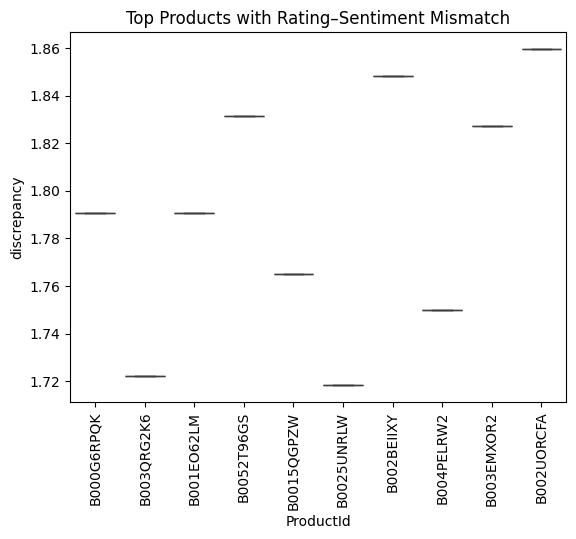

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

top_products = product_discrepancy.head(10).index

sns.boxplot(
    data=df[df["ProductId"].isin(top_products)],
    x="ProductId",
    y="discrepancy"
)

plt.xticks(rotation=90)
plt.title("Top Products with Rating–Sentiment Mismatch")
plt.show()

In [30]:
top_product = product_discrepancy.index[7]

df[df["ProductId"] == top_product][
    ["Summary", "Score", "sentiment_score", "discrepancy"]
].head(10)

,Summary,Score,sentiment_score,discrepancy
520262,Save your money! Buy a better tea.,1,0.75,1.75


## 2️⃣ Discovering Topics with Word2Vec + KMeans

We convert reviews into **Word2Vec embeddings** and cluster them using **KMeans**:  
- Each cluster represents a topic  
- We visualize clusters in 2D with **t-SNE**  
- This is **Approach 2** to answer **Research Question 2**


=== Top words per cluster ===

Cluster 0 top words: ['great', 'good', 'product', 'coffee', 'price', 'tea', 'snack', 'wonderful', 'perfect', 'quality']

Cluster 1 top words: ['delicious', 'yummy', 'tasty', 'flavor', 'healthy', 'sweet', 'good', 'nice', 'smooth', 'fresh']

Cluster 2 top words: ['tea', 'coffee', 'great', 'chocolate', 'flavor', 'good', 'hot', 'free', 'mix', 'green']

Cluster 3 top words: ['dog', 'loves', 'dogs', 'cat', 'great', 'cats', 'good', 'treats', 'happy', 'product']

=== Number of reviews per topic ===
             topic  num_reviews
0           Coffee        78230
1             Pets       152072
2  Snacks / Sweets        39148
3              Tea        93672


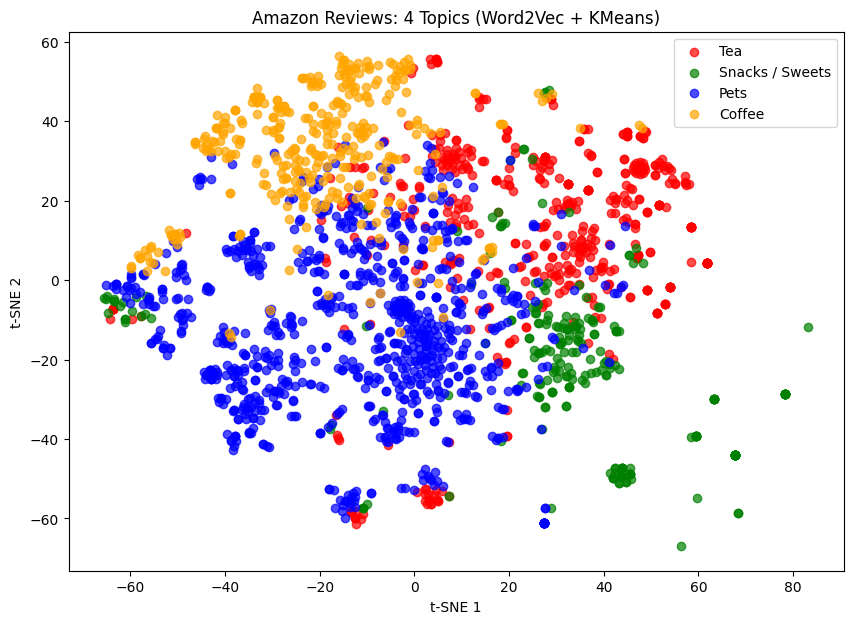

In [31]:
# ================================
# FINAL: Word2Vec + 4 Topic Clustering + Labels + t-SNE Plot
# ================================

from gensim.models import Word2Vec
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import re
import pandas as pd

# -----------------------------
# Step 0: Prepare positive reviews and stopwords
# -----------------------------
positive_reviews = df[df['Score'] == 5]['Summary']

stop_words = set(ENGLISH_STOP_WORDS)
extra_stopwords = {'love','best','like','just','favorite','way','awesome',
                   'excellent','stuff','taste','better','food','eat','ive','yum'}
all_stopwords = stop_words.union(extra_stopwords)

# -----------------------------
# Step 1: Clean reviews
# -----------------------------
def clean_text_simple(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

sentences = positive_reviews.apply(clean_text_simple).str.split()

# -----------------------------
# Step 2: Train Word2Vec model
# -----------------------------
w2v_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4
)

# -----------------------------
# Step 3: Convert each review to a vector (average word vectors)
# -----------------------------
def review_to_vec(words, model):
    vecs = [model.wv[word] for word in words if word in model.wv]
    if len(vecs) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

review_vectors = np.array([review_to_vec(r, w2v_model) for r in sentences])

# -----------------------------
# Step 4: Cluster reviews into 4 topics
# -----------------------------
num_clusters = 4
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
labels = kmeans.fit_predict(review_vectors)

# -----------------------------
# Step 5: Assign cluster labels to reviews
# -----------------------------
df_reviews = pd.DataFrame({
    'review': positive_reviews.tolist(),
    'cluster': labels,
    'clean_review': [" ".join(s) for s in sentences]
})

# -----------------------------
# Step 6: Print top 10 words per cluster (stopwords removed)
# -----------------------------
print("=== Top words per cluster ===")
for i in range(num_clusters):
    cluster_reviews = df_reviews[df_reviews['cluster']==i]['clean_review']
    words = " ".join(cluster_reviews).split()
    words = [w for w in words if w not in all_stopwords]
    most_common = [w for w,c in Counter(words).most_common(10)]
    print(f"\nCluster {i} top words: {most_common}")

# -----------------------------
# Step 7: Assign human-readable topic labels
# -----------------------------
cluster_topic_mapping = {
    0: "Tea",
    1: "Snacks / Sweets",
    2: "Pets",
    3: "Coffee"
}
df_reviews['topic'] = df_reviews['cluster'].map(cluster_topic_mapping)

# Optional: show cluster counts
topic_summary = df_reviews.groupby('topic').size().reset_index(name='num_reviews')
print("\n=== Number of reviews per topic ===")
print(topic_summary)

# -----------------------------
# Step 8: Visualize clusters in 2D using t-SNE (sample for speed)
# -----------------------------
sample_size = 2000
if len(review_vectors) > sample_size:
    X_sample = review_vectors[:sample_size]
    label_sample = labels[:sample_size]
else:
    X_sample = review_vectors
    label_sample = labels

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X_sample)

plt.figure(figsize=(10,7))
colors = ['red','green','blue','orange']
for i in range(num_clusters):
    idx = label_sample == i
    plt.scatter(X_2d[idx,0], X_2d[idx,1], label=cluster_topic_mapping[i], alpha=0.7, c=colors[i])
plt.legend()
plt.title("Amazon Reviews: 4 Topics (Word2Vec + KMeans)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()


## PCA-based Topic Visualization

We reduce the same Word2Vec embeddings to 2D using **PCA**:  
- Goal: show **global variance** and overall structure  
- t-SNE shows tight clusters, PCA shows variance directions


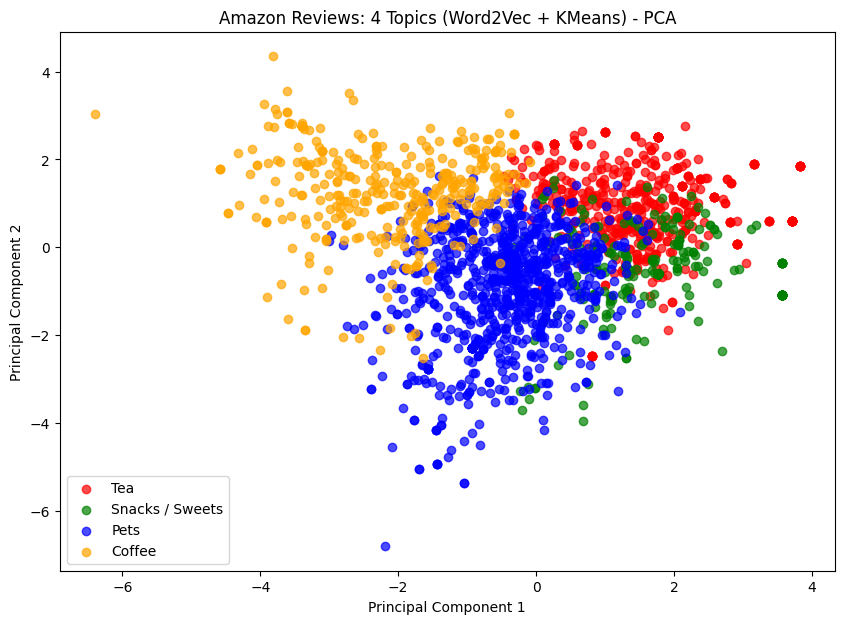

Explained variance ratio per component: [0.12434783 0.10073397]
Total variance explained: 0.22508179530329248


In [32]:
# ================================
# PCA Visualization (matching t-SNE)
# ================================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Make sure these variables exist (same as t-SNE)
# -----------------------------
num_clusters = 4
cluster_topic_mapping = {
    0: "Tea",
    1: "Snacks / Sweets",
    2: "Pets",
    3: "Coffee"
}
colors = ['red', 'green', 'blue', 'orange']  # same as t-SNE

# -----------------------------
# PCA transformation
# -----------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

# -----------------------------
# Plot PCA clusters
# -----------------------------
plt.figure(figsize=(10,7))
for i in range(num_clusters):
    idx = label_sample == i
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], 
                label=cluster_topic_mapping[i], alpha=0.7, c=colors[i])

plt.legend()
plt.title("Amazon Reviews: 4 Topics (Word2Vec + KMeans) - PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# -----------------------------
# Explained variance
# -----------------------------
print("Explained variance ratio per component:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())


# Conclusion

1. **Predicting Sentiment (Q1)**  
   - Logistic Regression on TF-IDF features achieved good accuracy.  
   - Text reviews can generally predict sentiment (positive, neutral, negative).

2. **Topics in Reviews (Q2)**  
   - LDA revealed main topics from the reviews.  
   - Word2Vec + KMeans gave similar topics with more compact clusters.  
   - t-SNE visualizations clearly separate topics, PCA shows overall variance structure.

3. **Rating–Sentiment Discrepancy (Q3)**  
   - Some products have large mismatches between review text sentiment and star rating.  
   - Identifying these helps find products with **inconsistent feedback** or **customer confusion**.

**Overall:**  
- Text analysis can uncover sentiment, topics, and inconsistencies in reviews.  
- Visualizations like **t-SNE and PCA** provide complementary views: local clusters vs global structure.  
- This analysis can guide product improvement, highlight customer concerns, and support data-driven decision making.
